# Introduction to matchms

`matchms` is an open-source Python library to handle, process, and compare MS/MS spectra. It is particularly geared towards large-scale similarity computations. In addition, matchms is intended to serve as a hub for developing new computational tools on top of it.

Some tools which are build on top of matchms:

+ [`Spec2Vec`](https://github.com/iomega/spec2vec) an alternative machine-learning spectral similarity score that can simply be installed by `pip install spec2vec` and be imported as `from spec2vec import Spec2Vec` following the same API as the scores in `matchms.similarity`.

+ [`MS2DeepScore`](https://github.com/matchms/ms2deepscore) a supervised, deep-learning based spectral similarity score that can simply be installed by `pip install ms2deepscore` and be imported as `from ms2deepscore import MS2DeepScore` following the same API as the scores in `matchms.similarity`.

+ [`MS2Query`](https://github.com/iomega/ms2query) Reliable and fast MS/MS spectral-based analogue search, running on top of matchms.

+ [`memo`](https://github.com/mandelbrot-project/memo) a method allowing a Retention Time (RT) agnostic alignment of metabolomics samples using the fragmentation spectra (MS2) of their constituents.

The source code of `matchms` is on GitHub --> https://github.com/matchms/matchms
This is also where you can interact with the developers of the tool (e.g., report problems, suggest new features, or: contribute yourself!).

In [1]:
# Necessary to install (if not present yet)
!pip install matchms

# Import libraries

In [2]:
import os
from matplotlib import pyplot as plt

from matchms import calculate_scores
from matchms.importing import load_from_mgf

## Import data
`matchms` can import and export MS/MS spectra from/to a few common formats such as .mgf, .msp, .mzxml, .json. Here we will simply import the example data as it came straight from MzMine.

### Download files

In [ ]:
! pip install gdown
import gdown

In [ ]:
#folder_id = "1IguoL163gDVu2r5J32ifJfFaJ6r_xAZm" #original folder
folder_id = "1V5ZEjIjZBa7lmHTBWPeXM9-2XeR5S5-Y" # test folder

In [ ]:
gdown.download_folder(id=folder_id, output="data", quiet=False, use_cookies=False)

### Upload folder and mount Google Drive
or we can mount the Google Drive folder (you need to upload your Data first)

In [ ]:
# Use this to mount your own google drive
from google.colab import drive
drive.mount('/content/drive')

In [3]:
# Specify data (and model) locations
#path_root = "./drive/MyDrive/summerschool2023_matchms"
#file = os.path.join(path_root, "data_mzmine", "example_iimn_gnps.mgf")
path_root = "data"
file = os.path.join(path_root, "example_iimn_gnps.mgf")

# Import spectra
spectra = list(load_from_mgf(file))

## What do we get from this?
Let's have a look at what the spectra now look like within matchms.

In [4]:
len(spectra)

3320

In [5]:
type(spectra)

list

In [6]:
spectra[0]

Spectrum(precursor m/z=185.98, 20 fragments between 59.9 and 163.0)

## matchms `Spectrum` objects
In `matchms` each MS/MS spectrum is handled as a `Spectrum` object.

- contains the MS/MS fragments --> `spectrum.peaks`  
The fragments are divided into m/z positions --> `spectrum.peaks.mz`  
and intensities --> `spectrum.peaks.intensities`
- contains the metadata --> `spectrum.metadata`

It also comes with basic functions (methods) to inspect or edit parts of the spectrum.
- basic plotting --> `spectrum.plot()`
- read metadata fields --> `spectrum.get("charge")`
- set metadata fields --> `spectrum.get("special_comments", "Nice!")`

### Mini-Exercise:
- How many fragments/peaks has the first spectrum in our list?
- What is the highest fragement m/z?
- Use the `.set()` method to add a "note_to_supervisor" field to the metadata and write into this field whatever you like (your superviser is likely to never read it...)
- Check if you indeed added the note by using the `.get()` method.

In [7]:
spectra[0].peaks

In [8]:
spectra[0].peaks.mz

array([ 59.941366,  75.936131,  77.951584,  84.960236,  93.946466,
        99.959854, 100.967526, 114.956833, 115.954378, 116.962259,
       117.969961, 117.979347, 118.977765, 132.957069, 133.964853,
       134.972636, 144.956866, 150.967418, 151.975532, 162.967556])

In [9]:
spectra[0].peaks.intensities

array([1801122.518835, 3342825.526213,  405899.456337, 1014853.926479,
       1414533.192861,  338880.223169, 4752954.324878,  329969.945528,
       4858221.894972, 4956352.74686 , 1855440.678754,  322040.771329,
       1629798.117844, 5655129.256048, 4234399.676941, 2906855.832912,
       2842251.345653, 2061166.834933,  461325.599569, 3382490.757561])

In [10]:
# Use Python for whatever you want to do...
for s in spectra:
    if len(s.peaks) > 10:
        s.set("unqualified_comments", "Awesome!")
    elif len(s.peaks) > 5:
        s.set("unqualified_comments", "Will do.")
    else:
        s.set("unqualified_comments", "Oh no.")

In [11]:
spectra[0].metadata

{'feature_id': '8',
 'feature_full_id': 'row8_mz185.983227_rt0.2129_id',
 'featurelist_feature_id': 'Aligned feature list 13C peak gaps dup corr PEARSON r greq 0.85 dp greq 5:8',
 'charge': 1,
 'feature_ms1_height': '1.296E6',
 'spectype': 'SAME_ENERGY',
 'merged_across_n_samples': '2',
 'collision_energy': '[30.0]',
 'fragmentation_method': 'HCD',
 'isolation_window': '1.5',
 'ionmode': 'positive',
 'source_scan_usi': '["mzspec:DATASET_ID_PLACEHOLDER:skin_10_240_UB:89","mzspec:DATASET_ID_PLACEHOLDER:skin_blank_20:83"]',
 'scans': '8',
 'num_peaks': '20',
 'ms_level': '2',
 'retention_time': 12.78,
 'file_name': 'skin_10_240_UB.mzML;skin_blank_20.mzML',
 'precursor_mz': 185.98323,
 'unqualified_comments': 'Awesome!'}

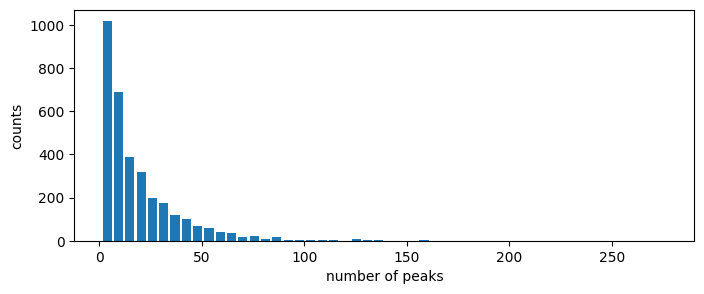

In [12]:
number_of_peaks = [len(s.peaks) for s in spectra]

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(number_of_peaks, bins=50, rwidth=0.8)
ax.set_ylabel("counts")
ax.set_xlabel("number of peaks")
plt.show()

## Process spectra

`matchms` comes with many filtering functions (in `matchms.filtering`). Even better: If you want something very specific or novel, you can also build your own filters. And even better yet: you could become a co-developer of matchms and add a filter you miss to the library!

In general, there are filters with focus on the **metadata**. For instance to correct, add, edit, harmonize specific metadata fields. And there are filters for the **fragments**, for instance to remove small peaks, normalize peak intensities etc.

From matchms 0.22 on (made right before this summerschool), the central element to apply filters is the `SpectrumProcessor`.

Here, we will apply:
- A few default filters to harmonize metadata
- Normalize peak intensities (to max=1.0)
- Remove all peaks outside 10.0 to 1000.0 Da m/z window
- Remove spectra with < 4 remaining peaks

The last two teps are potentially important for tools like `Spec2Vec` or `MS2DeepScore` which make predictions solely based on the MS2 peaks.

In [13]:
from matchms import SpectrumProcessor
from matchms.filtering.default_pipelines import BASIC_FILTERS

min_number_peaks = 4

# Define filter pipeline
processor = SpectrumProcessor(BASIC_FILTERS)
processor.parse_and_add_filter("normalize_intensities")
processor.parse_and_add_filter(("select_by_mz", {"mz_from": 10, "mz_to": 1000}))
processor.parse_and_add_filter(("require_minimum_number_of_peaks", {"n_required": min_number_peaks}))

# Apply filter pipeline
spectra_cleaned, _ = processor.process_spectra(spectra)
print(f"Number of remaining spectra: {len(spectra_cleaned)}")

Processing spectra:  60%|███████████████████████████████████████████████████████████████▍                                         | 2004/3320 [00:02<00:01, 957.31it/s]

2025-07-21 19:45:41,351:WARNING:matchms:clean_adduct:The charge in the adduct: [M+Na]+ and the given charge: 2 do not match


Processing spectra:  70%|████████████████████████████████████████████████████████████████████████▊                               | 2324/3320 [00:02<00:00, 1015.34it/s]

2025-07-21 19:45:41,683:WARNING:matchms:clean_adduct:The charge in the adduct: [M+NH4]+ and the given charge: 2 do not match
2025-07-21 19:45:41,697:WARNING:matchms:clean_adduct:The charge in the adduct: [M+H]+ and the given charge: 2 do not match


Processing spectra: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 3320/3320 [00:03<00:00, 1002.17it/s]

Number of remaining spectra: 2773


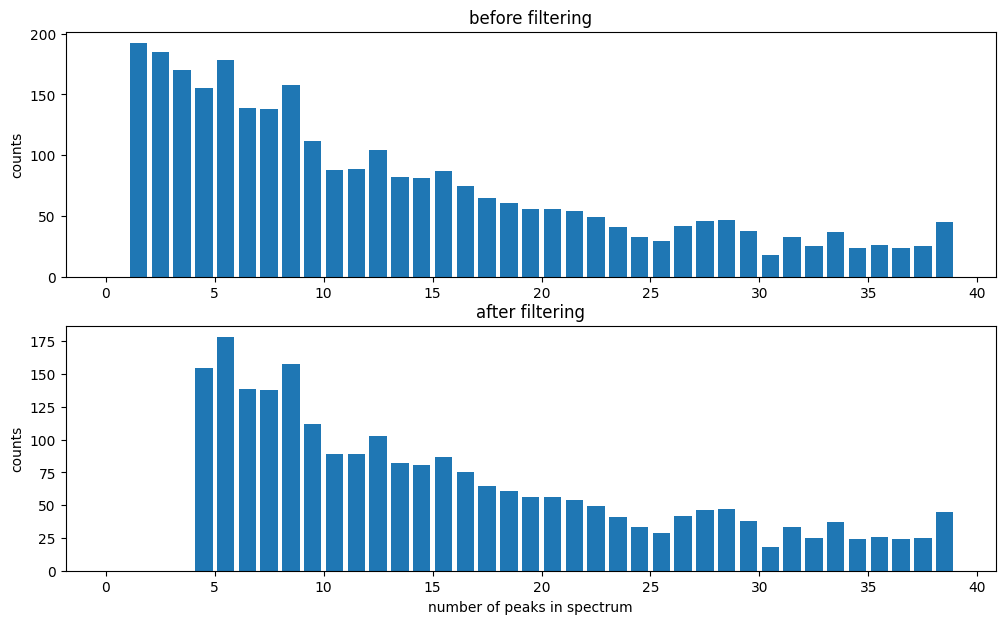

In [14]:
import numpy as np

bins = np.arange(0, 40, 1)
# Plots
fig, (ax1, ax2) = plt.subplots(2, figsize=(12, 7))
ax1.hist([len(s.peaks) for s in spectra], bins=bins, rwidth=0.8)
ax1.set_title("before filtering")
ax1.set_ylabel("counts")
ax2.hist([len(s.peaks) for s in spectra_cleaned], bins=bins, rwidth=0.8)
ax2.set_title("after filtering")
ax2.set_ylabel("counts")
ax2.set_xlabel("number of peaks in spectrum")
plt.show()

In [15]:
spectra_cleaned[0].metadata

{'feature_id': '8',
 'feature_full_id': 'row8_mz185.983227_rt0.2129_id',
 'featurelist_feature_id': 'Aligned feature list 13C peak gaps dup corr PEARSON r greq 0.85 dp greq 5:8',
 'charge': 1,
 'feature_ms1_height': '1.296E6',
 'spectype': 'SAME_ENERGY',
 'merged_across_n_samples': '2',
 'collision_energy': '[30.0]',
 'fragmentation_method': 'HCD',
 'isolation_window': '1.5',
 'ionmode': 'positive',
 'source_scan_usi': '["mzspec:DATASET_ID_PLACEHOLDER:skin_10_240_UB:89","mzspec:DATASET_ID_PLACEHOLDER:skin_blank_20:83"]',
 'scans': '8',
 'num_peaks': '20',
 'ms_level': '2',
 'retention_time': 12.78,
 'file_name': 'skin_10_240_UB.mzML;skin_blank_20.mzML',
 'precursor_mz': 185.98323,
 'unqualified_comments': 'Awesome!',
 'retention_index': None,
 'inchikey': '',
 'inchi': '',
 'smiles': ''}

In [16]:
for s in spectra_cleaned:
    s.set("ionmode", "positive")

# Check if it worked
spectra_cleaned[0].metadata

{'feature_id': '8',
 'feature_full_id': 'row8_mz185.983227_rt0.2129_id',
 'featurelist_feature_id': 'Aligned feature list 13C peak gaps dup corr PEARSON r greq 0.85 dp greq 5:8',
 'charge': 1,
 'feature_ms1_height': '1.296E6',
 'spectype': 'SAME_ENERGY',
 'merged_across_n_samples': '2',
 'collision_energy': '[30.0]',
 'fragmentation_method': 'HCD',
 'isolation_window': '1.5',
 'ionmode': 'positive',
 'source_scan_usi': '["mzspec:DATASET_ID_PLACEHOLDER:skin_10_240_UB:89","mzspec:DATASET_ID_PLACEHOLDER:skin_blank_20:83"]',
 'scans': '8',
 'num_peaks': '20',
 'ms_level': '2',
 'retention_time': 12.78,
 'file_name': 'skin_10_240_UB.mzML;skin_blank_20.mzML',
 'precursor_mz': 185.98323,
 'unqualified_comments': 'Awesome!',
 'retention_index': None,
 'inchikey': '',
 'inchi': '',
 'smiles': ''}

## Basic plotting (only for quick inspection)

(<Figure size 1600x1200 with 1 Axes>,
 <Axes: title={'center': 'Spectrum'}, xlabel='m/z', ylabel='Intensity'>)

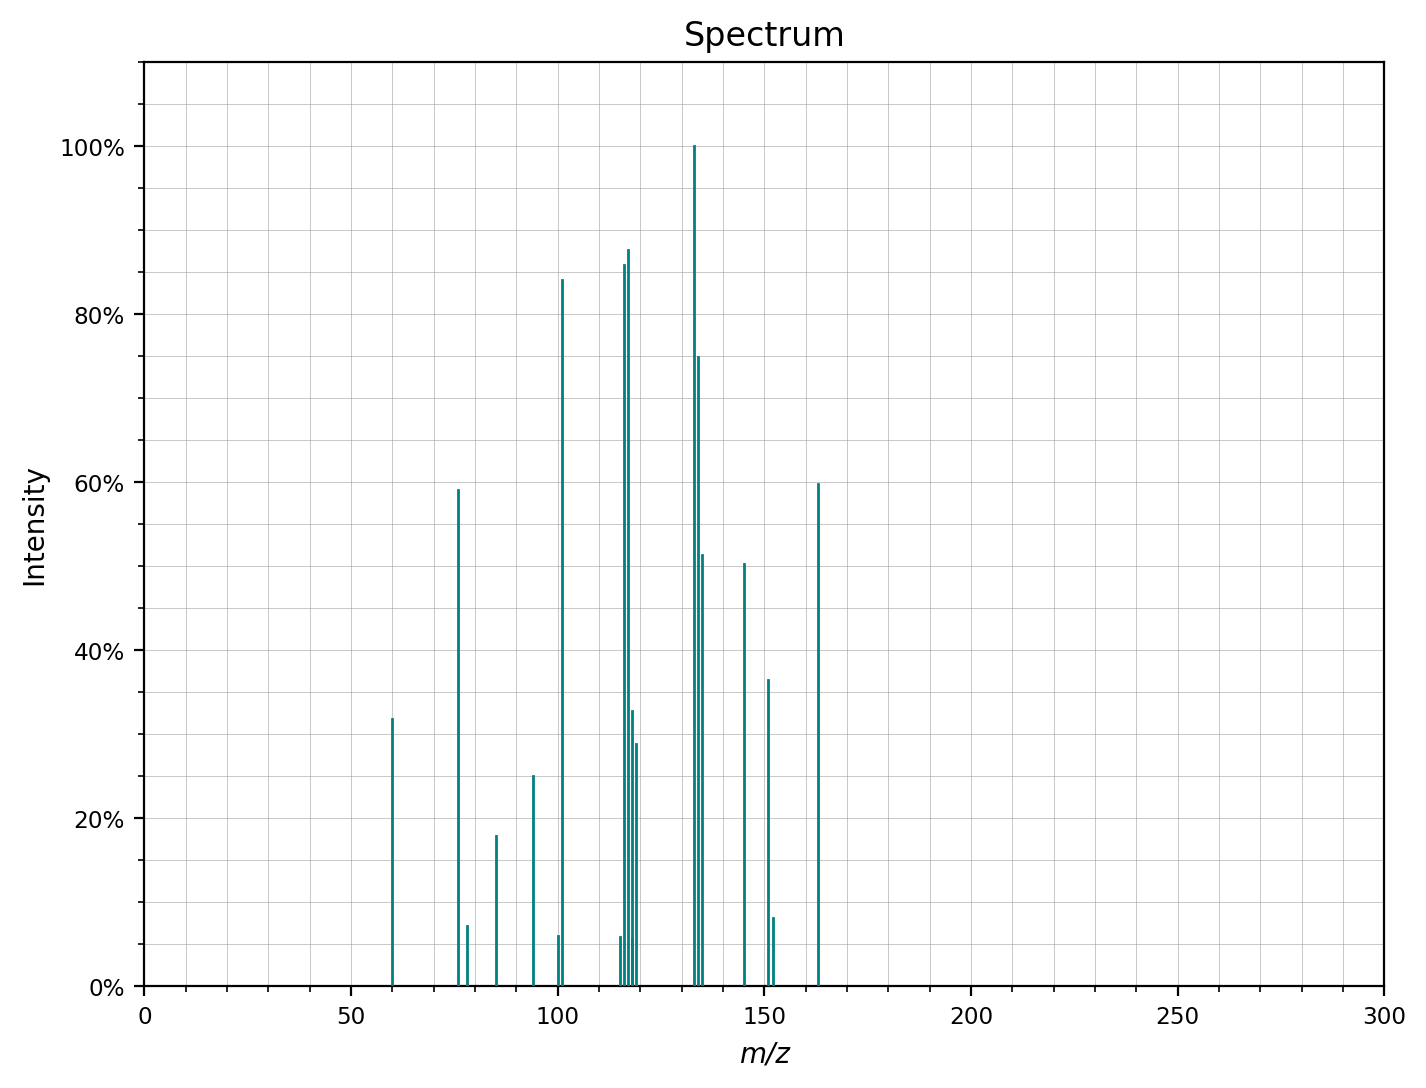

In [17]:
spectra_cleaned[0].plot()

(<Figure size 1600x1200 with 1 Axes>,
 <Axes: title={'center': 'Spectrum comparison'}, xlabel='m/z', ylabel='Intensity'>)

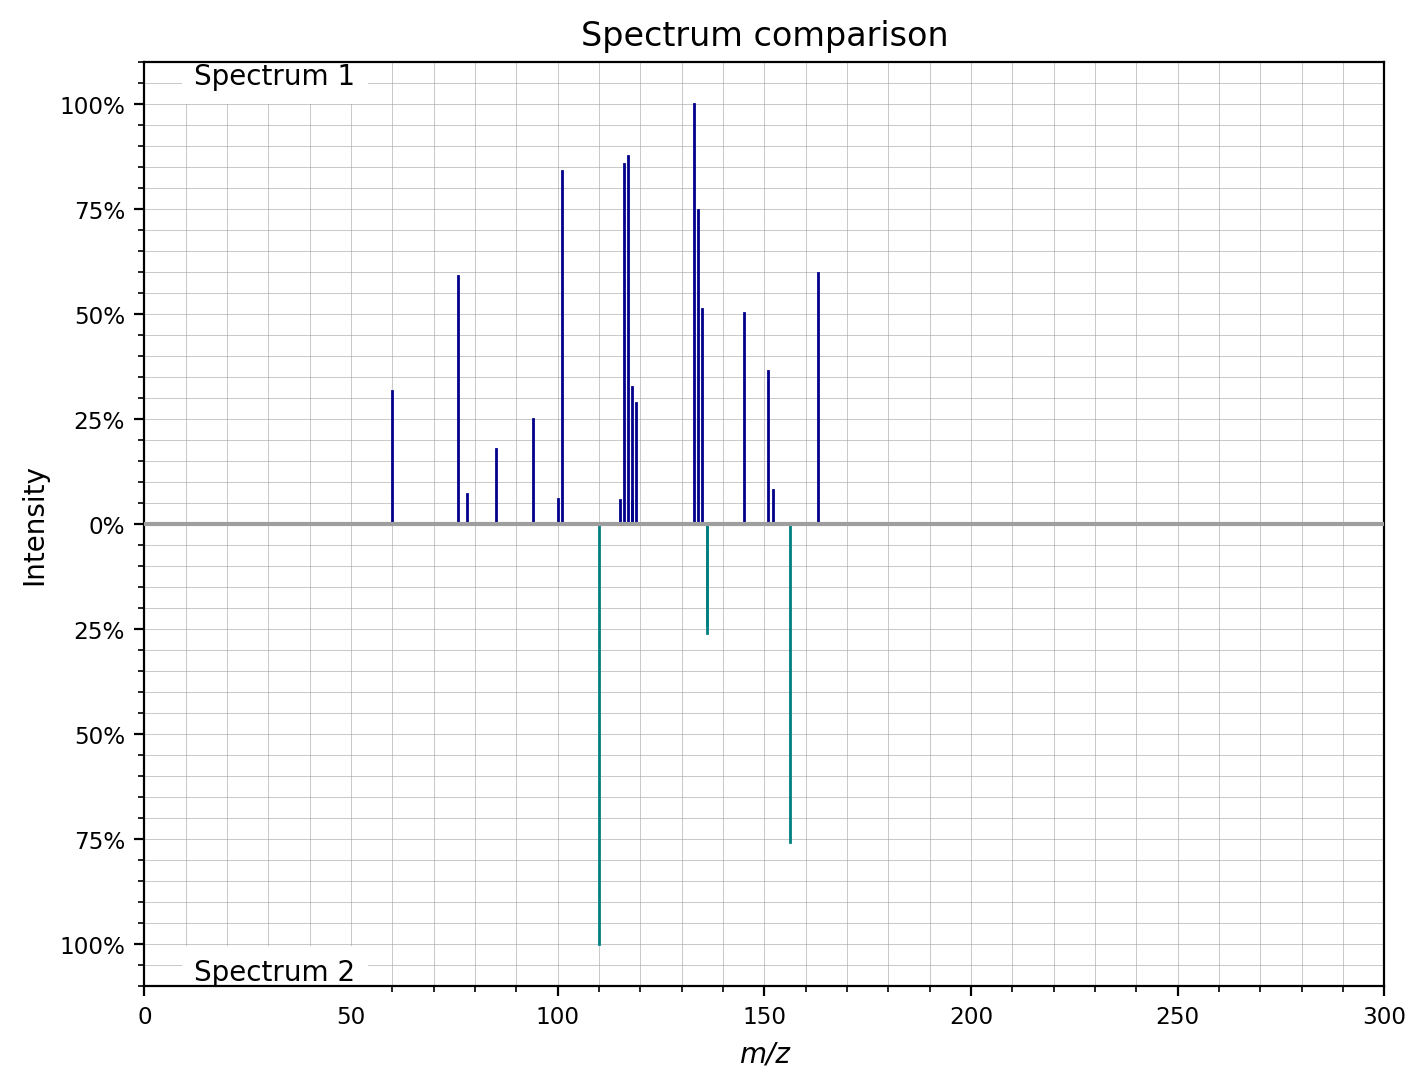

In [18]:
spectra_cleaned[0].plot_against(spectra_cleaned[151])

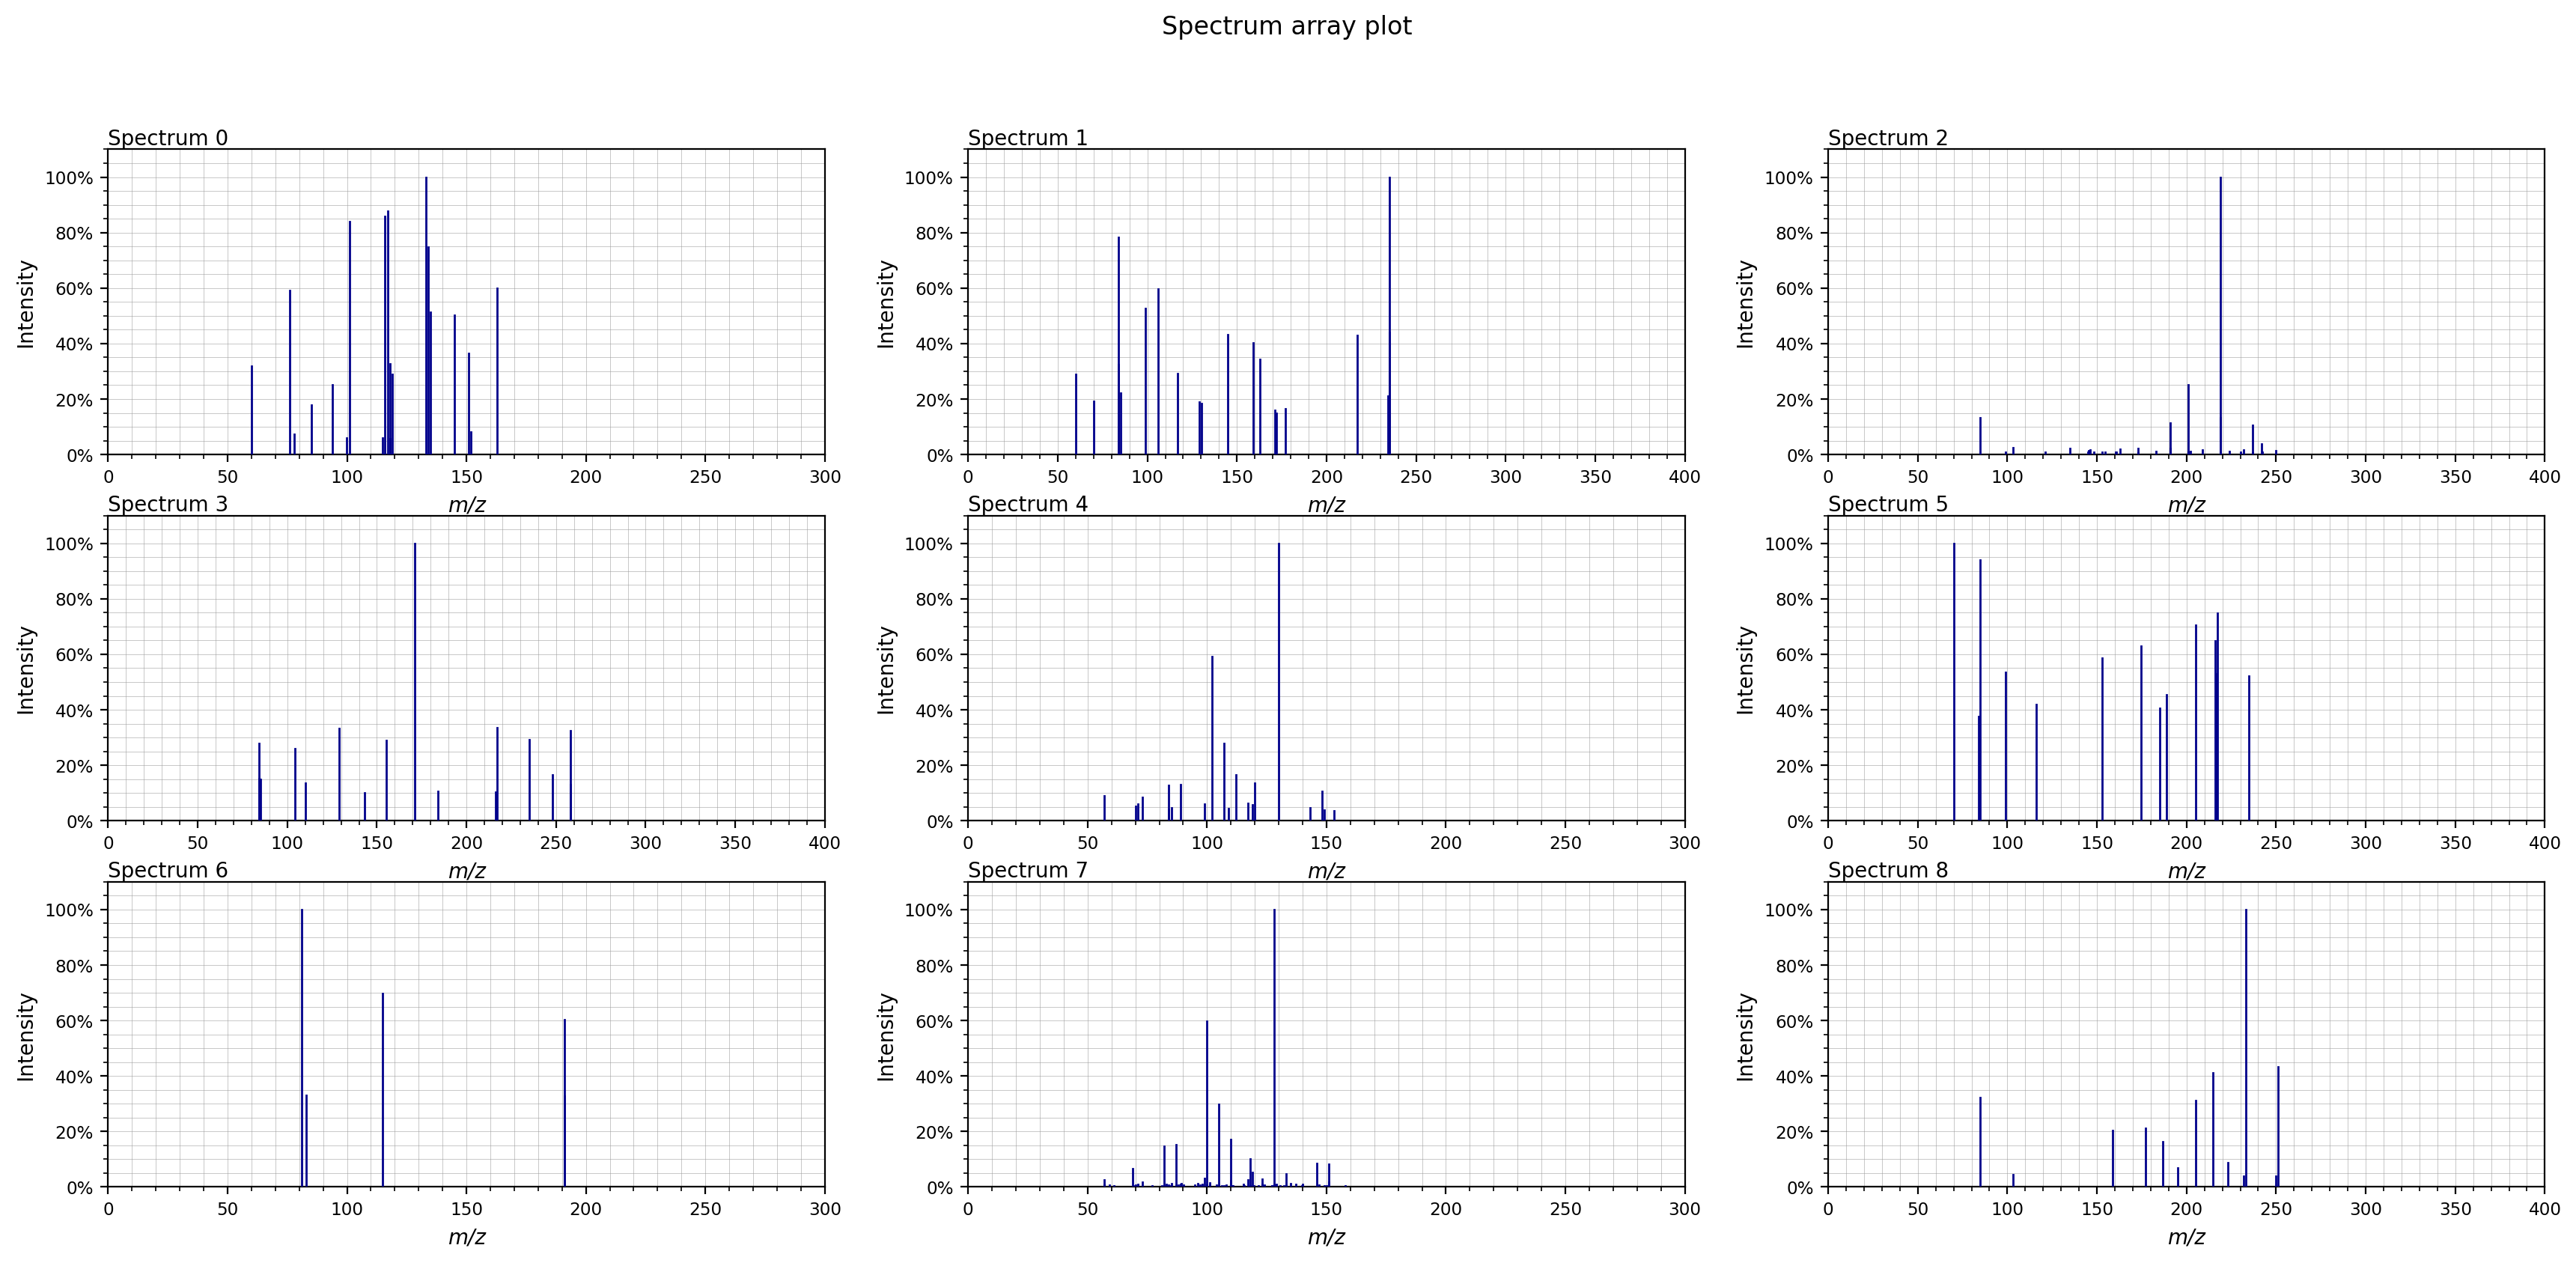

In [19]:
from matchms.plotting import plot_spectra_array

plot_spectra_array(spectra_cleaned[:9], 3)
plt.show()

## Spectrum similarity computation

Matchms comes with several spectrm similarity scores such as:
- Cosine (`CosineGreedy`)
- Modified Cosine (`ModifiedCosine`)
- Molecular fingerprint based scoring (`FingerprintSimilarity`)
- Precursor m/z matching (`PrecursorMzMatch`)

A core feature, however, is that you can also build (program) your own similarity measures or import other compatible ones (for instance: `Spec2Vec` or `MS2DeepScore`).

In [20]:
from matchms.similarity import PrecursorMzMatch, CosineGreedy

similarity_measure = PrecursorMzMatch(tolerance=0.1,
                                      tolerance_type="Dalton")
scores = calculate_scores(spectra_cleaned, spectra_cleaned, similarity_measure)
scores

<2773x2773x1 stacked sparse array containing scores for ('PrecursorMzMatch',) with 23693 stored elements in COOrdinate format>

In [21]:
# what is this number for?
3802 ** 2

14455204

In [22]:
scores.scores

<2773x2773x1 stacked sparse array containing scores for ('PrecursorMzMatch',) with 23693 stored elements in COOrdinate format>

In [23]:
cosine_similarity = CosineGreedy(tolerance=0.01)
scores.calculate(cosine_similarity)

Calculating sparse similarities: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 23693/23693 [00:02<00:00, 9530.84it/s]


<2773x2773x3 stacked sparse array containing scores for ('PrecursorMzMatch', 'CosineGreedy_score', 'CosineGreedy_matches') with 23693 stored elements in COOrdinate format>

In [24]:
scores.scores

<2773x2773x3 stacked sparse array containing scores for ('PrecursorMzMatch', 'CosineGreedy_score', 'CosineGreedy_matches') with 23693 stored elements in COOrdinate format>

In [25]:
print(scores.to_array()[:3, :3])

[[(1., 1., 20) (0., 0.,  0) (0., 0.,  0)]
 [(0., 0.,  0) (1., 1., 21) (0., 0.,  0)]
 [(0., 0.,  0) (0., 0.,  0) (1., 1., 35)]]


In [26]:
results = scores.scores_by_query(spectra_cleaned[2], "CosineGreedy_score", sort=True)
results

[(Spectrum(precursor m/z=242.00, 35 fragments between 85.0 and 250.0),
  np.void((1.0, 1.0000000000000007, 35), dtype=[('PrecursorMzMatch', '<f8'), ('CosineGreedy_score', '<f8'), ('CosineGreedy_matches', '<i8')]))]

### Remove scores below threshold

In [27]:
scores.filter_by_range(name="CosineGreedy_score",
                       low= 0.7)

In [28]:
scores.scores

<2773x2773x3 stacked sparse array containing scores for ('PrecursorMzMatch', 'CosineGreedy_score', 'CosineGreedy_matches') with 5765 stored elements in COOrdinate format>

In [29]:
results = scores.scores_by_query(spectra_cleaned[1], 'CosineGreedy_score', sort=True)
results

[(Spectrum(precursor m/z=234.96, 21 fragments between 60.0 and 235.1),
  np.void((1.0, 1.0000000000000002, 21), dtype=[('PrecursorMzMatch', '<f8'), ('CosineGreedy_score', '<f8'), ('CosineGreedy_matches', '<i8')]))]

(<Figure size 1600x1200 with 1 Axes>,
 <Axes: title={'center': 'Spectrum comparison'}, xlabel='m/z', ylabel='Intensity'>)

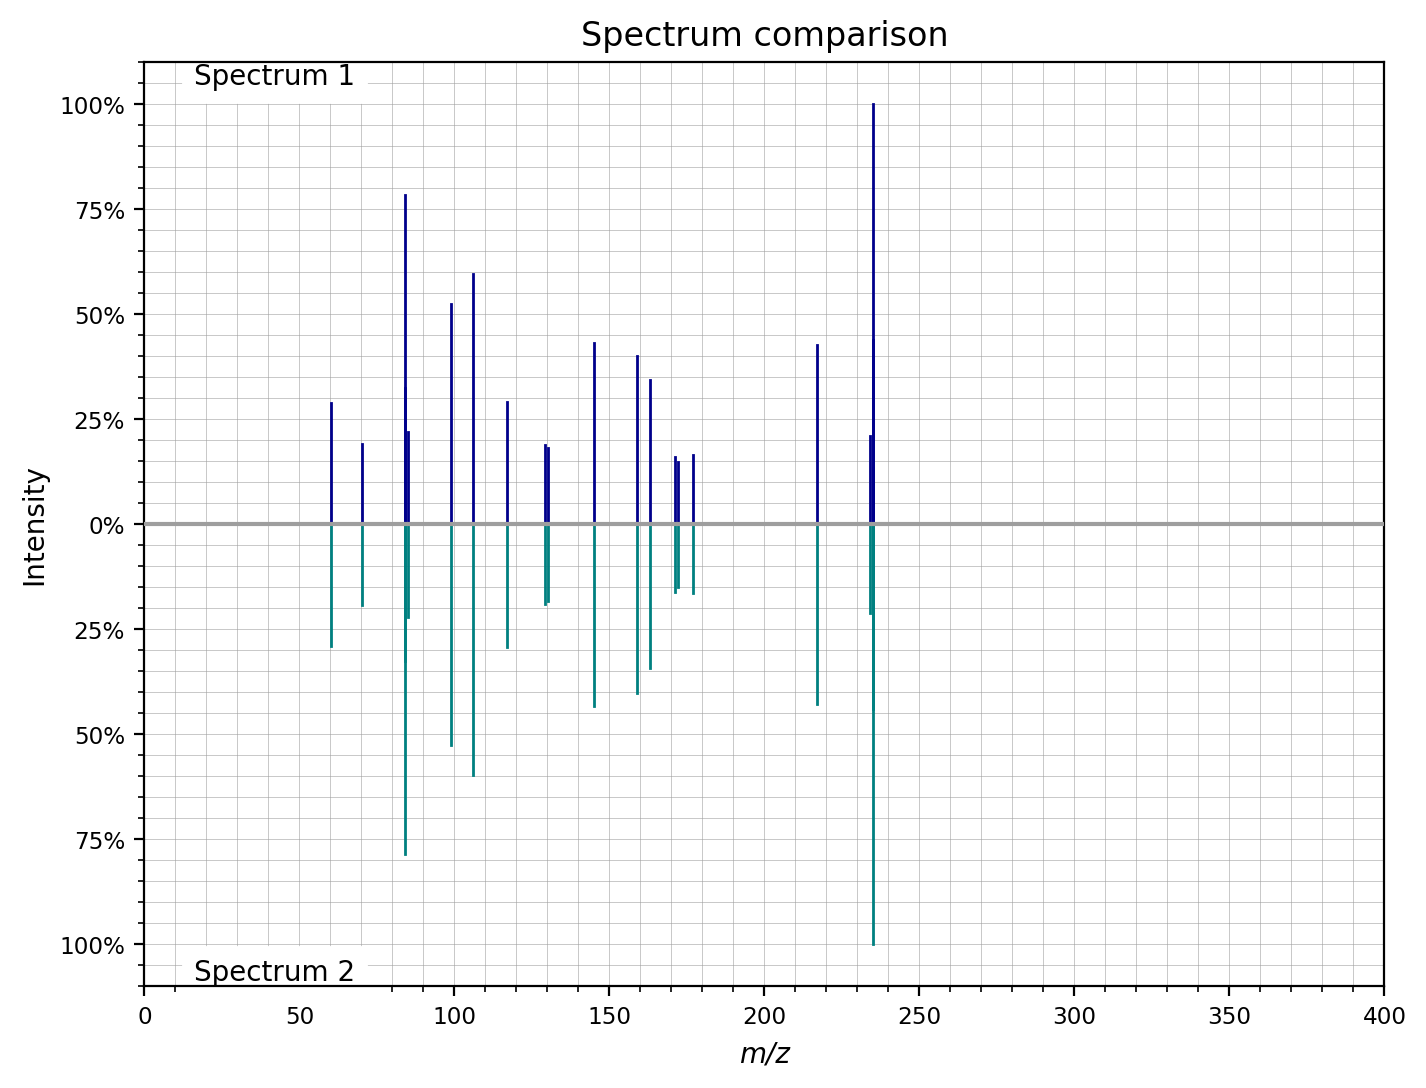

In [33]:
spectra_cleaned[1].plot_against(results[0][0])

(<Figure size 2800x600 with 2 Axes>,
 array([[<Axes: xlabel='m/z', ylabel='Intensity'>, <Axes: >]], dtype=object))

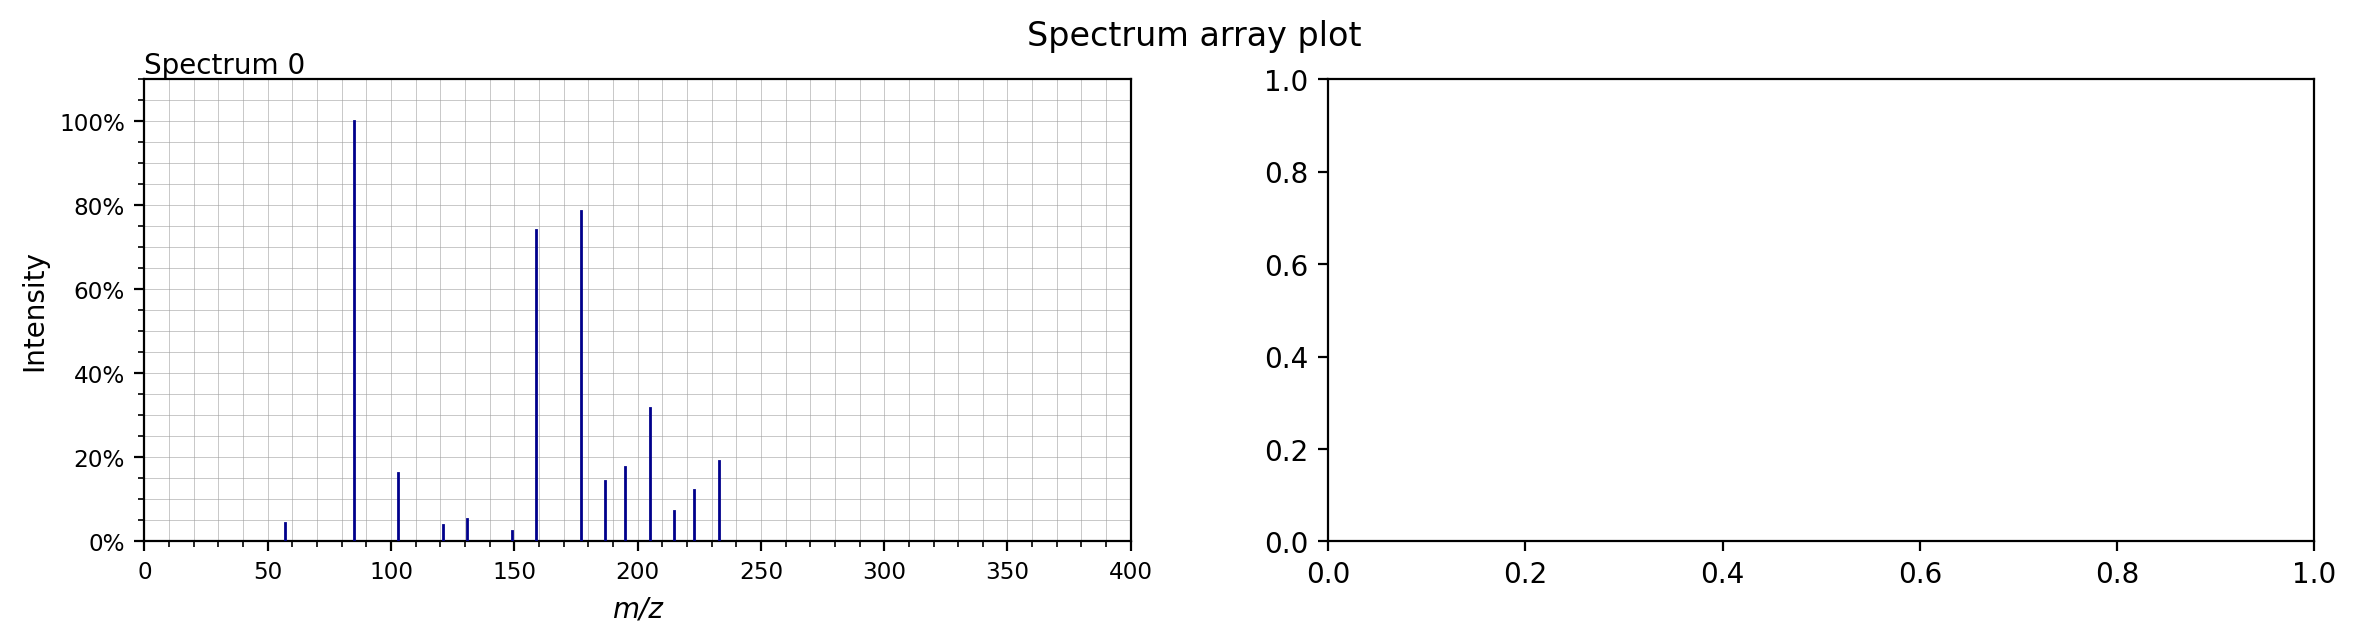

In [34]:
results = scores.scores_by_query(spectra_cleaned[10], 'CosineGreedy_score', sort=True)
plot_spectra_array([x[0] for x in results[:8]])